Lab2: machine learning
Lamar Alhimali S23108185


In [1]:
import sklearn
print(f"scikit-learn version: {sklearn.__version__}")

import numpy as np
import matplotlib.pyplot as plt

print("All libraries loaded successfully!")


scikit-learn version: 1.6.1
All libraries loaded successfully!


In [2]:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target

print(iris.feature_names)
print(iris.target_names)
print(X.shape)


['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']
(150, 4)


TASK1

In [3]:
for i in range(10):
    print(f"X[{i}]={X[i]}   y[{i}]={y[i]} ({iris.target_names[y[i]]})")


X[0]=[5.1 3.5 1.4 0.2]   y[0]=0 (setosa)
X[1]=[4.9 3.  1.4 0.2]   y[1]=0 (setosa)
X[2]=[4.7 3.2 1.3 0.2]   y[2]=0 (setosa)
X[3]=[4.6 3.1 1.5 0.2]   y[3]=0 (setosa)
X[4]=[5.  3.6 1.4 0.2]   y[4]=0 (setosa)
X[5]=[5.4 3.9 1.7 0.4]   y[5]=0 (setosa)
X[6]=[4.6 3.4 1.4 0.3]   y[6]=0 (setosa)
X[7]=[5.  3.4 1.5 0.2]   y[7]=0 (setosa)
X[8]=[4.4 2.9 1.4 0.2]   y[8]=0 (setosa)
X[9]=[4.9 3.1 1.5 0.1]   y[9]=0 (setosa)


In [4]:
import numpy as np
print(np.unique(y, return_counts=True))


(array([0, 1, 2]), array([50, 50, 50]))


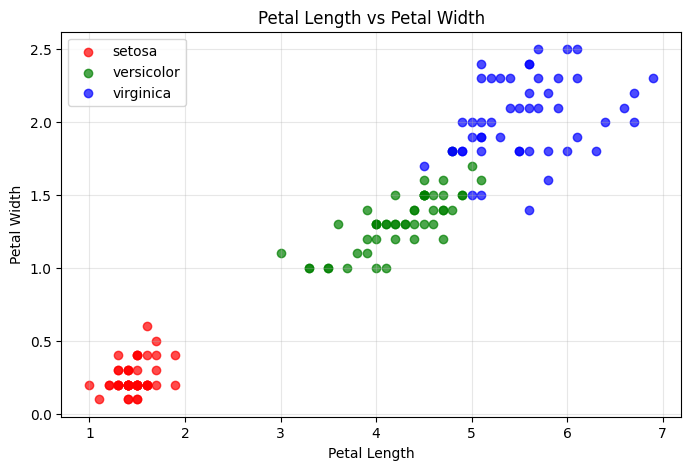

In [5]:
plt.figure(figsize=(8,5))
colors = ['red','green','blue']
for i, name in enumerate(iris.target_names):
    mask = (y == i)
    plt.scatter(X[mask, 2], X[mask, 3], color=colors[i], label=name, alpha=0.7)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Petal Length vs Petal Width")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Petal features separate classes better than sepal features

SPLIT DATA TASK2


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)


(120, 4) (30, 4)


In [7]:
print("Train:", np.unique(y_train, return_counts=True))
print("Test:", np.unique(y_test, return_counts=True))


Train: (array([0, 1, 2]), array([40, 40, 40]))
Test: (array([0, 1, 2]), array([10, 10, 10]))


In [8]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Without stratify - Train:", np.unique(y_train2, return_counts=True))
print("Without stratify - Test:", np.unique(y_test2, return_counts=True))


Without stratify - Train: (array([0, 1, 2]), array([40, 41, 39]))
Without stratify - Test: (array([0, 1, 2]), array([10,  9, 11]))


With stratify, class proportions stay balanced; without it, they may become uneven.

TASK3

In [9]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

print("DT first 10:", dt_predictions[:10])
print("True first 10:", y_test[:10])


DT first 10: [0 2 1 1 0 1 0 0 2 1]
True first 10: [0 2 1 1 0 1 0 0 2 1]


In [10]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_predictions = knn_model.predict(X_test)

print("KNN first 10:", knn_predictions[:10])


KNN first 10: [0 2 1 1 0 1 0 0 2 1]


In [11]:
for k in [3, 10]:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    print(f"k={k} first 10:", p[:10])


k=3 first 10: [0 2 1 1 0 1 0 0 2 1]
k=10 first 10: [0 2 1 1 0 1 0 0 2 1]


Changing k changes predictions because the neighbor vote changes

TASK4

In [12]:
from sklearn.metrics import accuracy_score, classification_report

print("DT accuracy:", accuracy_score(y_test, dt_predictions))
print("KNN accuracy:", accuracy_score(y_test, knn_predictions))

print("\nDT report:\n", classification_report(y_test, dt_predictions, target_names=iris.target_names))
print("\nKNN report:\n", classification_report(y_test, knn_predictions, target_names=iris.target_names))


DT accuracy: 0.9333333333333333
KNN accuracy: 1.0

DT report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


KNN report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



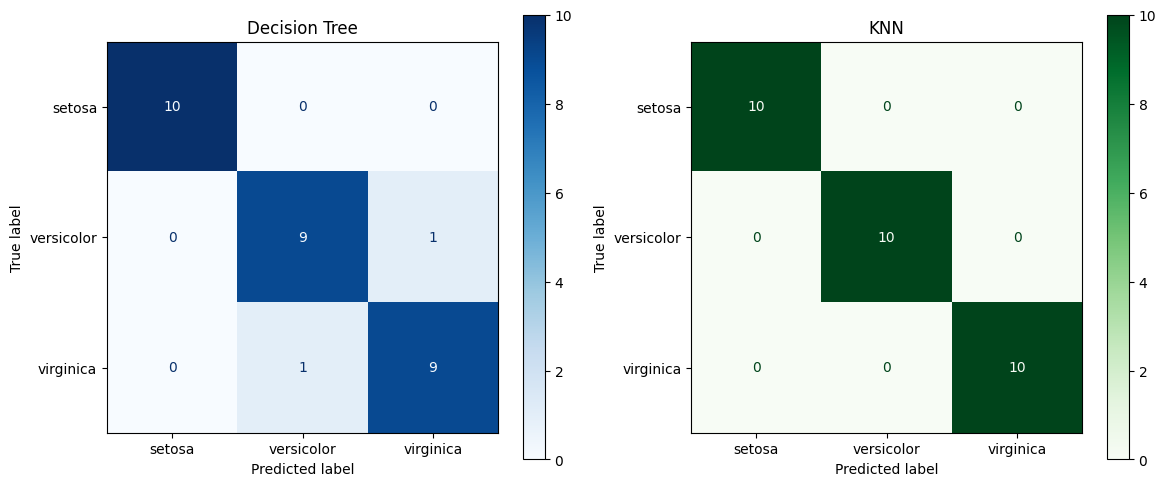

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12,5))

cm_dt = confusion_matrix(y_test, dt_predictions)
ConfusionMatrixDisplay(cm_dt, display_labels=iris.target_names).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Decision Tree")

cm_knn = confusion_matrix(y_test, knn_predictions)
ConfusionMatrixDisplay(cm_knn, display_labels=iris.target_names).plot(ax=axes[1], cmap="Greens")
axes[1].set_title("KNN")

plt.tight_layout()
plt.show()


Higher accuracy: write whichever is bigger

Hardest class: usually Versicolor vs Virginica (overlap)

Medical diagnosis: Recall (avoid missing sick patients)

TASK5

In [14]:
import numpy as np

flowers = {
    "A": [6.7, 3.0, 5.2, 2.3],
    "B": [5.8, 2.7, 4.1, 1.0],
    "C": [4.9, 3.1, 1.5, 0.1]
}

for name, vals in flowers.items():
    sample = np.array([vals])
    dt_p = dt_model.predict(sample)[0]
    knn_p = knn_model.predict(sample)[0]
    print(name, "DT:", iris.target_names[dt_p], "| KNN:", iris.target_names[knn_p])


A DT: virginica | KNN: virginica
B DT: versicolor | KNN: versicolor
C DT: setosa | KNN: setosa


Do they agree? (yes/no based on output)

If not: trust the one with higher test accuracy and better confusion matrix.

TASK6

In [15]:
import pandas as pd
import numpy as np

np.random.seed(42)
n=100
data = {
    "study_hours": np.round(np.random.uniform(1,10,n),1),
    "attendance_pct": np.round(np.random.uniform(40,100,n),1),
    "assignments": np.random.randint(3,10,n),
    "passed": np.random.choice([0,1], n, p=[0.35,0.65])
}
df = pd.DataFrame(data)
df.to_csv("students.csv", index=False)
df.head()


,study_hours,attendance_pct,assignments,passed
0,4.4,41.9,6,0
1,9.6,78.2,5,1
2,7.6,58.9,3,1
3,6.4,70.5,6,1
4,2.4,94.5,8,1


In [16]:
df = pd.read_csv("students.csv")
print(df.describe())
df.info()


       study_hours  attendance_pct  assignments      passed
count   100.000000      100.000000   100.000000  100.000000
mean      5.233000       69.871000     6.000000    0.690000
std       2.681438       17.583476     1.959179    0.464823
min       1.000000       40.400000     3.000000    0.000000
25%       2.775000       54.500000     4.750000    0.000000
50%       5.150000       70.350000     6.000000    1.000000
75%       7.600000       85.975000     8.000000    1.000000
max       9.900000       99.100000     9.000000    1.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_hours     100 non-null    float64
 1   attendance_pct  100 non-null    float64
 2   assignments     100 non-null    int64  
 3   passed          100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X = df[["study_hours","attendance_pct","assignments"]].values
y = df["passed"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_p = dt.predict(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_p = knn.predict(X_test)

print("DT accuracy:", accuracy_score(y_test, dt_p))
print("KNN accuracy:", accuracy_score(y_test, knn_p))


DT accuracy: 0.55
KNN accuracy: 0.6


In [18]:
df["quiz_score"] = np.round(np.random.uniform(0,10,len(df)),1)

X2 = df[["study_hours","attendance_pct","assignments","quiz_score"]].values
y2 = df["passed"].values

X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

dt2 = DecisionTreeClassifier(random_state=42)
dt2.fit(X_train, y_train)
dt2_p = dt2.predict(X_test)

knn2 = KNeighborsClassifier(n_neighbors=5)
knn2.fit(X_train, y_train)
knn2_p = knn2.predict(X_test)

print("DT accuracy (with quiz):", accuracy_score(y_test, dt2_p))
print("KNN accuracy (with quiz):", accuracy_score(y_test, knn2_p))


DT accuracy (with quiz): 0.65
KNN accuracy (with quiz): 0.65


In this experiment, both Decision Tree and K-Nearest Neighbors (KNN) models were trained on the student performance dataset. Before adding the new feature, the Decision Tree achieved an accuracy of 0.55, while KNN achieved an accuracy of 0.60, meaning KNN performed slightly better initially. After adding the new feature quiz_score, both models improved and achieved an accuracy of 0.65. This shows that adding additional relevant features can help improve model performance. Since both models achieved the same accuracy after adding the new feature, either model could be selected; however, Decision Trees are often easier to interpret, while KNN depends on distance between neighbors.

Decision Tree and K-Nearest Neighbors (KNN) were used to classify data and their performance was compared using accuracy scores. Before adding the new feature, KNN achieved a higher accuracy (0.60) compared to the Decision Tree (0.55), showing that KNN initially performed better. After adding the new feature “quiz_score”, both models improved and achieved the same accuracy of 0.65. Decision Trees work by creating rule-based splits, which makes them easy to interpret and understand. KNN, on the other hand, classifies samples based on similarity to neighboring data points and depends on the value of k. For this task, I would choose the Decision Tree because it provides similar performance after improvement but is more interpretable and easier to explain. Overall, both models performed well, but feature engineering played an important role in improving results.